In [1]:
import math


def logaddexp(a, b):
    """
    Stable log(exp(a) + exp(b)).
    Handles -inf correctly.
    """
    if a == -math.inf:
        return b
    if b == -math.inf:
        return a
    if a > b:
        return a + math.log1p(math.exp(b - a))
    else:
        return b + math.log1p(math.exp(a - b))


def degeneracy_box(d, k):
    if d == 1:
        root = int(math.sqrt(k))
        if root * root == k and root > 0:
            return 1
        return 0
    elif d == 2:
        count = 0
        max_n = int(math.sqrt(k))
        for nx in range(1, max_n + 1):
            ny_sq = k - nx**2
            if ny_sq > 0:
                ny = int(math.sqrt(ny_sq))
                if ny**2 == ny_sq:
                    count += 1
        return count
    else:
        count = 0
        max_n = int(math.sqrt(k))
        for nx in range(1, max_n + 1):
            count += degeneracy_box(d - 1, k - nx**2)
        return count

def level_degeneracy(d, k):
    """
    Default degeneracy:
        g_k = binom(d + k - 1, k)
    """
    if d < 1:
        raise ValueError("d must be a positive integer.")
    return math.comb(d + k - 1, k)


def log_binom(n, k):
    """
    log(binomial(n, k)) using log-gamma.
    """
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


def fermion_logZ_numeric(
    tau,
    N,
    n,
    d=None,
    max_shell=None,
    tol=1e-4,
    consecutive_small=8,
    safety_cap=100000,
    return_all=False,
    gk_fn=None,
    Ek_fn=None,
    logwk_fn=None,
    k_start=0,
):
    """
    Compute log(Z_n) for the canonical partition function using
    log-space polynomial convolution.

    General generating function:
        Xi(t) = prod_{k >= k_start} (1 + w_k t)^(g_k)

    Default choice:
        g_k = binom(d + k - 1, k)
        w_k = b^k

    so if no custom functions are supplied, this reproduces the original model
    except that k can start at 0 or 1.

    Parameters
    ----------
    tau : float
    N : int
        Number of beads.
    n : int
        Number of particles.
    d : int or None
        Dimension. Required if gk_fn is not supplied.
    max_shell : int or None
        If given, use shells k = k_start..max_shell.
        If None, truncate adaptively.
    tol : float
        Relative tolerance for adaptive stopping, measured in log-space.
    consecutive_small : int
        Require this many consecutive tiny updates before stopping.
    safety_cap : int
        Maximum number of shell indices checked in adaptive mode.
    return_all : bool
        If True, return (logZ_n, logZ_array, info_dict).
    gk_fn : callable or None
        Custom degeneracy function gk_fn(k).
        If None, use level_degeneracy(d, k).
    Ek_fn : callable or None
        Custom exponent function E_k, so that w_k = b^(E_k).
    logwk_fn : callable or None
        Custom function logwk_fn(k, logb) returning log(w_k) directly.
        This overrides Ek_fn.
    k_start : int
        Starting shell index, usually 0 or 1.

    Notes
    -----
    - If both Ek_fn and logwk_fn are None, the default is E_k = k.
    - logZ[m] = log(coefficient of t^m).
    """

    if N <= 0:
        raise ValueError("N must be a positive integer.")
    if n < 0:
        raise ValueError("n must be a nonnegative integer.")
    if tau < 0:
        raise ValueError("tau must be nonnegative.")
    if max_shell is not None and max_shell < k_start:
        raise ValueError("max_shell must be >= k_start.")
    if k_start < 0:
        raise ValueError("k_start must be nonnegative.")

    if gk_fn is None and d is None:
        raise ValueError("Provide d for the default degeneracy, or provide gk_fn.")
    if d is not None and d <= 0:
        raise ValueError("d must be a positive integer.")

    epsilon = tau / N
    zeta = 1.0 + 0.5 * epsilon * epsilon
    u = math.log(zeta + math.sqrt(zeta * zeta - 1.0))
    b = math.exp(-N * u)
    logb = -N * u  # log(b)

    # Defaults
    if gk_fn is None:
        gk_fn = lambda k: degeneracy_box(d, k)

    if logwk_fn is None:
        if Ek_fn is None:
            Ek_fn = lambda k: k
        logwk_fn = lambda k, logb: Ek_fn(k) * logb

    # logZ[m] = log coefficient of t^m in running polynomial
    logZ = [-math.inf] * (n + 1)
    logZ[0] = 0.0

    if n == 0:
        info = {
            "epsilon": epsilon,
            "zeta": zeta,
            "u": u,
            "b": b,
            "logb": logb,
            "shells_used": 0,
            "k_start": k_start,
        }
        return (0.0, logZ, info) if return_all else 0.0

    def convolve_shell_logspace(logZ, g, logw, n):
        """
        Multiply current polynomial by (1 + w t)^g in log-space, truncated to degree n.

        Local coefficients:
            C_m = binom(g, m) w^m
        so
            log C_m = log binom(g,m) + m logw
        """
        if g < 0 or int(g) != g:
            raise ValueError(f"g_k must be a nonnegative integer, got {g}.")
        g = int(g)

        mmax = min(g, n)

        logC = [0.0] * (mmax + 1)
        logC[0] = 0.0
        for m in range(1, mmax + 1):
            logC[m] = log_binom(g, m) + m * logw

        old = logZ[:]

        for r in range(n + 1):
            s = -math.inf
            upper = min(r, mmax)
            for m in range(upper + 1):
                if old[r - m] != -math.inf:
                    s = logaddexp(s, logC[m] + old[r - m])
            logZ[r] = s

    if max_shell is not None:
        shells_used = 0
        for k in range(k_start, max_shell + 1):
            gk = gk_fn(k)
            logwk = logwk_fn(k, logb)
            convolve_shell_logspace(logZ, gk, logwk, n)
            shells_used += 1

    else:
        shells_used = 0
        prev_logZn = -math.inf
        small_count = 0
        cumulative_capacity = 0

        for offset in range(safety_cap + 1):
            k = k_start + offset
            gk = gk_fn(k)
            logwk = logwk_fn(k, logb)
            convolve_shell_logspace(logZ, gk, logwk, n)

            shells_used += 1
            cumulative_capacity += int(gk)

            if cumulative_capacity >= n:
                curr = logZ[n]

                if prev_logZn != -math.inf and curr != -math.inf:
                    delta_log = abs(curr - prev_logZn)
                    if delta_log <= tol:
                        small_count += 1
                    else:
                        small_count = 0

                prev_logZn = curr

                if small_count >= consecutive_small:
                    break
        else:
            raise RuntimeError(
                "Adaptive truncation did not converge. "
                "Try increasing safety_cap or set max_shell explicitly."
            )

    if return_all:
        info = {
            "epsilon": epsilon,
            "zeta": zeta,
            "u": u,
            "b": b,
            "logb": logb,
            "shells_used": shells_used,
            "k_start": k_start,
        }
        return logZ[n], logZ, info

    return logZ[n]

In [11]:
import numpy as np

# ==========================================
# USER INPUTS: Define your potential here
# ==========================================

# Integration Domain
x_min = -1.0
x_max = 1.0
num_grid = 800

def user_potential(x):
    """
    Define the separable 1D potential V(x).
    Must be able to accept a NumPy array x and return an array of the same shape.
    """
    # --- Example 1: Hard Wall (Infinite Square Well) ---
    # (V=0 inside domain, boundary is handled by x_min, x_max)
    return np.zeros_like(x)

    # --- Example 2: Harmonic Oscillator ---
    # w = 1.0
    # return 0.5 * (w**2) * (x**2)

    # --- Example 3: Double Well ---
    # return (x**2 - 1.0)**2

    # Example 4: Periodic potential
    # V0 = 5.0
    # k = 2.0 * np.pi
    # return V0 * np.sin(k * x)**2

    # Example 5: Anharmonic Oscillator
    # w = 1.0
    # lambda_param = 0.5
    # return 0.5 * (w**2) * (x**2) + lambda_param * (x**4)

    # Example 6: Linear Potential
    # force = 2.0
    # # Combine with a hard wall at x=0
    # V = force * x
    # V[x < 0] = np.inf
    # return V



# Parameters for testing
n = 5
d = 2
N = [2]


In [7]:
import numpy as np
import scipy.linalg as la

def get_1d_log_eigenvalues(tau, N, x_min, x_max, num_grid):
    epsilon = tau / N
    x = np.linspace(x_min, x_max, num_grid)
    dx = (x_max - x_min) / (num_grid - 1)
    
    X, Y = np.meshgrid(x, x)
    
    # Calculate Potential Energy components
    Vx = user_potential(X)
    Vy = user_potential(Y)
    
    # Calculate Kinetic Matrix
    K_kinetic = (1.0 / np.sqrt(2 * np.pi * epsilon)) * np.exp(-((X - Y)**2) / (2 * epsilon))
    
    # Symmetric Trotter Breakup for Primitive Approximation
    T = np.exp(-epsilon * Vx / 2.0) * K_kinetic * np.exp(-epsilon * Vy / 2.0) * dx
    
    # Extract eigenvalues of the symmetric transfer matrix
    eigvals = la.eigvalsh(T)
    eigvals = eigvals[eigvals > 1e-15] # filter numerical noise
    return np.log(np.sort(eigvals)[::-1])

def get_nd_log_eigenvalues(tau, N, d, x_min, x_max, num_grid, max_states=1000):
    log_eig1 = get_1d_log_eigenvalues(tau, N, x_min, x_max, num_grid)
    
    if d == 1:
        return log_eig1[:max_states]
    elif d == 2:
        # Sum of logs for products of eigenvalues
        log_eig2 = []
        for i in range(len(log_eig1)):
            for j in range(len(log_eig1)):
                if log_eig1[i] + log_eig1[j] > -100:
                    log_eig2.append(log_eig1[i] + log_eig1[j])
        log_eig2 = np.array(log_eig2)
        log_eig2.sort()
        return log_eig2[::-1][:max_states]
    else:
        raise NotImplementedError("Only d=1 and d=2 are implemented for numerical eigenvalues.")

class NumericalEigenvalueLogW:
    def __init__(self, tau, N, d, x_min, x_max, num_grid, max_states=400):
        self.log_eigvals = get_nd_log_eigenvalues(tau, N, d, x_min, x_max, num_grid, max_states)
        self.N = N
        self.max_shell = len(self.log_eigvals) - 1
        
    def gk_fn(self, k):
        return 1
        
    def logwk_fn(self, k, logb):
        return self.log_eigvals[k] * self.N

def fermion_logZ_numeric_pimc_predict(tau, N, n, d=None, **kwargs):
    # Calculate eigenvalues dynamically for the given tau and N using user_potential
    num_eig = NumericalEigenvalueLogW(tau, N, d, x_min, x_max, num_grid, max_states=max(n*4, 100))
    
    # Remove kwargs that conflict
    kwargs.pop('k_start', None)
    kwargs.pop('max_shell', None)
    kwargs.pop('gk_fn', None)
    kwargs.pop('logwk_fn', None)
    kwargs.pop('Ek_fn', None)
    
    return fermion_logZ_numeric(
        tau=tau, N=N, n=n, d=d, k_start=0, max_shell=num_eig.max_shell,
        gk_fn=num_eig.gk_fn, logwk_fn=num_eig.logwk_fn,
        **kwargs
    )


In [8]:
import matplotlib.pyplot as plt


def make_tau_grid(tau_start, tau_end, tau_step):
    if tau_step <= 0:
        raise ValueError("tau_step must be positive.")
    if tau_end < tau_start:
        raise ValueError("tau_end must be >= tau_start.")

    taus = []
    tau = tau_start
    while tau <= tau_end + 1e-15:
        taus.append(round(tau, 12))
        tau += tau_step
    return taus


def finite_difference_user_sign(x, y):
    """
    Computes:
        (y_i - y_{i+1}) / (x_{i+1} - x_i)

    So if y = logZ(tau), this is:
        (logZ(tau) - logZ(tau + dt)) / dt
    """
    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")
    if len(x) < 2:
        raise ValueError("Need at least 2 points.")

    x_fd = x[:-1]
    y_fd = []
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        y_fd.append((y[i] - y[i + 1]) / dx)
    return x_fd, y_fd


def plot_logZ_and_fd_multiN(tau_start, tau_end, tau_step, n, d, N_list,
                            show_logZ=True, show_fd=True, logZ_func=fermion_logZ_numeric, **logZ_kwargs):
    """
    Requires fermion_logZ_numeric(...) to already be defined.

    Parameters
    ----------
    tau_start, tau_end, tau_step : float
    n : int
    d : int
    N_list : list of ints
    show_logZ : bool
    show_fd : bool
    **logZ_kwargs :
        Any extra keyword args passed to fermion_logZ_numeric,
        e.g. max_shell=..., tol=..., consecutive_small=..., safety_cap=...
    """
    taus = make_tau_grid(tau_start, tau_end, tau_step)
    results = {}

    for N in N_list:
        logZ_vals = [
            logZ_func(tau=tau, N=N, n=n, d=d, **logZ_kwargs)
            for tau in taus
        ]
        tau_fd, fd_vals = finite_difference_user_sign(taus, logZ_vals)

        results[N] = {
            "taus": taus,
            "logZ": logZ_vals,
            "tau_fd": tau_fd,
            "fd": fd_vals,
        }

    if show_logZ:
        plt.figure(figsize=(8, 5))
        for N in N_list:
            plt.plot(results[N]["taus"], results[N]["logZ"], marker=".", label=f"N={N}")
        plt.xlabel("tau")
        plt.ylabel("log Z_n")
        plt.title(f"log Z_n vs tau (n={n}, d={d})")
        plt.grid(True)
        plt.legend()
        plt.show()

    if show_fd:
        plt.figure(figsize=(8, 5))
        for N in N_list:
            plt.plot(results[N]["tau_fd"], results[N]["fd"], marker=".", label=f"N={N}")
        plt.xlabel("tau")
        plt.ylabel("(log Z(tau) - log Z(tau + dt)) / dt")
        plt.title(f"Finite difference vs tau (n={n}, d={d})")
        plt.grid(True)
        plt.legend()
        plt.show()

    return results

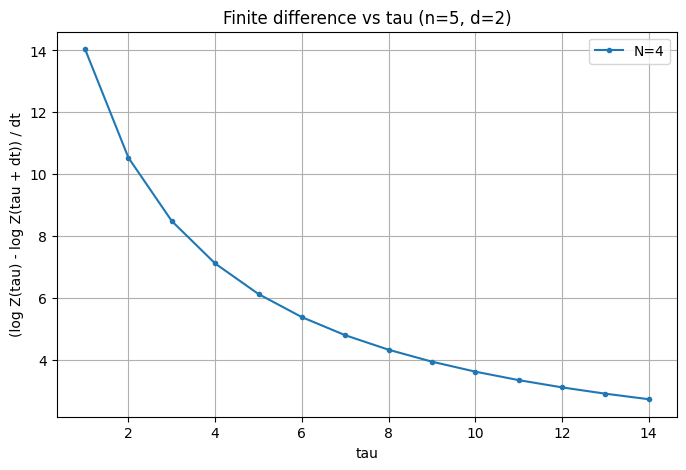

In [10]:
results = plot_logZ_and_fd_multiN(
    tau_start=1.0,
    tau_end=15.0,
    tau_step=1.0,
    
    n=n,
    d=d,
    N_list=N,
    show_logZ=False,
    show_fd=True,
    logZ_func=fermion_logZ_numeric_pimc_predict
)


In [43]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def scaling_model(n, a, b, c):
    return a * (n ** b) + c


def fit_runtime_scaling(tau, N, d, n_start=0, n_end=2000, n_step=25,
                        repeats=3, use_median=True, **logZ_kwargs):
    """
    Times fermion_logZ_numeric(...) for n = n_start, n_start+n_step, ..., n_end
    at fixed tau, N, d, then fits runtime to

        t(n) = a * n^b + c

    Parameters
    ----------
    repeats : int
        Number of timing runs per n.
    use_median : bool
        If True, use median runtime across repeats.
        If False, use mean runtime.
    **logZ_kwargs
        Extra kwargs passed to fermion_logZ_numeric(...)

    Returns
    -------
    dict with n values, runtimes, fit params, covariance
    """
    n_vals = np.arange(n_start, n_end + 1, n_step, dtype=int)
    runtimes = []

    for n in n_vals:
        samples = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            fermion_logZ_numeric(tau=tau, N=N, n=int(n), d=d, **logZ_kwargs)
            t1 = time.perf_counter()
            samples.append(t1 - t0)

        runtime = float(np.median(samples) if use_median else np.mean(samples))
        runtimes.append(runtime)

    runtimes = np.array(runtimes, dtype=float)

    # avoid starting guess issues
    c0 = float(runtimes.min())
    a0 = max(float(runtimes.max() - c0), 1e-12)
    b0 = 1.0

    popt, pcov = curve_fit(
        scaling_model,
        n_vals.astype(float),
        runtimes,
        p0=(a0, b0, c0),
        maxfev=20000
    )

    return {
        "n_vals": n_vals,
        "runtimes": runtimes,
        "params": {
            "a": popt[0],
            "b": popt[1],
            "c": popt[2],
        },
        "cov": pcov,
    }


def plot_runtime_scaling_fit(tau, N, d, n_start=0, n_end=2000, n_step=25,
                             repeats=3, use_median=True, **logZ_kwargs):
    result = fit_runtime_scaling(
        tau=tau,
        N=N,
        d=d,
        n_start=n_start,
        n_end=n_end,
        n_step=n_step,
        repeats=repeats,
        use_median=use_median,
        **logZ_kwargs
    )

    n_vals = result["n_vals"]
    runtimes = result["runtimes"]
    a = result["params"]["a"]
    b = result["params"]["b"]
    c = result["params"]["c"]

    n_fit = np.linspace(n_vals.min(), n_vals.max(), 400)
    t_fit = scaling_model(n_fit, a, b, c)

    plt.figure(figsize=(8, 5))
    plt.plot(n_vals, runtimes, "o", label="measured runtime")
    plt.plot(n_fit, t_fit, label=f"fit: a*n^b + c\n a={a:.6g}, b={b:.6g}, c={c:.6g}")
    plt.xlabel("n")
    plt.ylabel("runtime (seconds)")
    plt.title(f"Runtime scaling at tau={tau}, N={N}, d={d}")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"a = {a}")
    print(f"b = {b}")
    print(f"c = {c}")

    return result

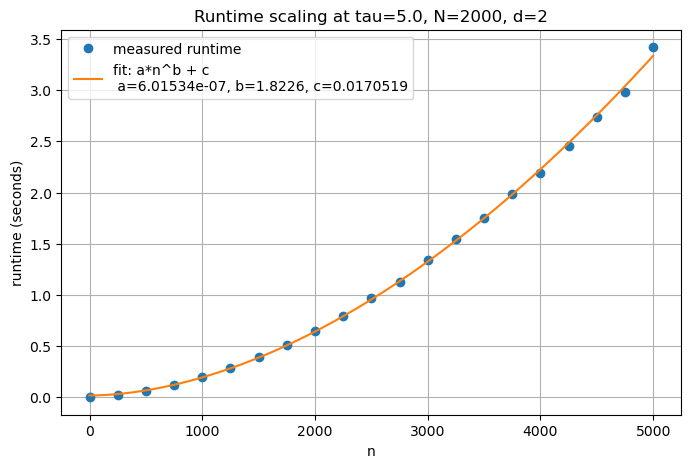

a = 6.015343056242236e-07
b = 1.8226005026883911
c = 0.017051926225865707


In [46]:
result = plot_runtime_scaling_fit(
    tau=5.0,
    N=2000,
    d=2,
    n_start=0,
    n_end=5000,
    n_step=250,
    repeats=5
)

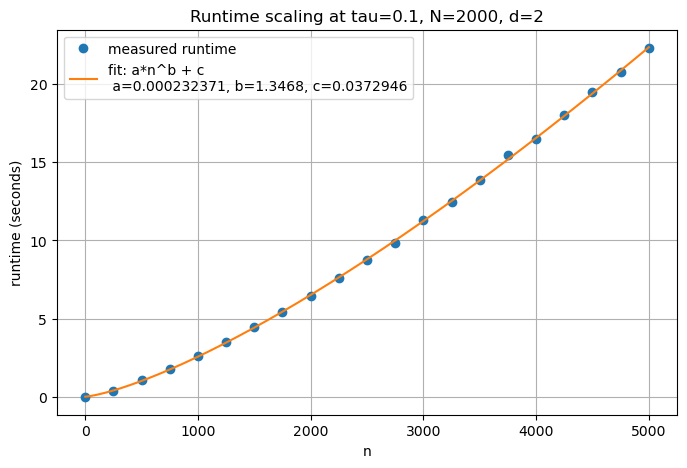

a = 0.00023237114858821304
b = 1.3467967659746622
c = 0.037294624983741385


In [95]:
result = plot_runtime_scaling_fit(
    tau=0.1,
    N=2000,
    d=2,
    n_start=0,
    n_end=5000,
    n_step=250,
    repeats=3
)

In [73]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def scaling_model_tau_negpow(tau, a, b, c):
    return a * (tau ** (-b)) + c


def highest_shell_zero_temp_from_your_script(n):
    """
    Same shell-filling logic as your script, but returns the highest shell index.
    """
    cur_lvl = 0
    total_eng = 0
    m = n

    while n > 0:
        for i in range(0, cur_lvl):
            if n > 0:
                total_eng += cur_lvl - 1
                n -= 1
            else:
                break
        cur_lvl += 1

    highest_shell = cur_lvl
    print("Highest shell:", highest_shell)
    return highest_shell


def fit_runtime_vs_tau_negpow(tau_start, tau_end, tau_step, N, n, d,
                              repeats=3, use_median=True, **logZ_kwargs):
    """
    Assumes fermion_logZ_numeric(..., return_all=True) returns:
        (logZ_n, logZ_array, info_dict)
    with info_dict containing:
        info["shells_used"]
    """
    tau_vals = np.arange(tau_start, tau_end + 0.5 * tau_step, tau_step, dtype=float)
    runtimes = []
    shell_counts = []

    for tau in tau_vals:
        samples = []
        shell_used_this_tau = None

        for _ in range(repeats):
            t0 = time.perf_counter()
            _, _, info = fermion_logZ_numeric(
                tau=float(tau),
                N=N,
                n=n,
                d=d,
                return_all=True,
                **logZ_kwargs
            )
            t1 = time.perf_counter()
            samples.append(t1 - t0)

            if shell_used_this_tau is None:
                shell_used_this_tau = info["shells_used"]

        runtime = float(np.median(samples) if use_median else np.mean(samples))
        runtimes.append(runtime)
        shell_counts.append(shell_used_this_tau)

    runtimes = np.array(runtimes, dtype=float)
    shell_counts = np.array(shell_counts, dtype=int)

    c0 = float(runtimes.min())
    a0 = max(float(runtimes.max() - c0), 1e-12)
    b0 = 1.0

    popt, pcov = curve_fit(
        scaling_model_tau_negpow,
        tau_vals,
        runtimes,
        p0=(a0, b0, c0),
        maxfev=20000
    )

    return {
        "tau_vals": tau_vals,
        "runtimes": runtimes,
        "shell_counts": shell_counts,
        "params": {
            "a": popt[0],
            "b": popt[1],
            "c": popt[2],
        },
        "cov": pcov,
    }


def plot_runtime_vs_tau_negpow_fit(tau_start, tau_end, tau_step, N, n, d,
                                   repeats=3, use_median=True, print_shells=True,
                                   **logZ_kwargs):
    result = fit_runtime_vs_tau_negpow(
        tau_start=tau_start,
        tau_end=tau_end,
        tau_step=tau_step,
        N=N,
        n=n,
        d=d,
        repeats=repeats,
        use_median=use_median,
        **logZ_kwargs
    )

    tau_vals = result["tau_vals"]
    runtimes = result["runtimes"]
    shell_counts = result["shell_counts"]
    a = result["params"]["a"]
    b = result["params"]["b"]
    c = result["params"]["c"]

    tau_fit = np.linspace(tau_vals.min(), tau_vals.max(), 400)
    t_fit = scaling_model_tau_negpow(tau_fit, a, b, c)

    print(f"a = {a}")
    print(f"b = {b}")
    print(f"c = {c}")

    if print_shells:
        print("\nStopping shell count for each tau:")
        for tau, k in zip(tau_vals, shell_counts):
            print(f"tau = {tau:8.4f}, shells_used = {k}")

    # First plot: runtime fit
    plt.figure(figsize=(8, 5))
    plt.plot(tau_vals, runtimes, "o", label="measured runtime")
    plt.plot(
        tau_fit,
        t_fit,
        label=f"fit: a*tau^(-b) + c\n a={a:.6g}, b={b:.6g}, c={c:.6g}"
    )
    plt.xlabel("tau")
    plt.ylabel("runtime (seconds)")
    plt.title(f"Runtime vs tau at N={N}, n={n}, d={d}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Zero-temp highest occupied shell from your shell-filling script
    highest_shell_0T = highest_shell_zero_temp_from_your_script(n)

    # Second plot: shells_used vs tau
    plt.figure(figsize=(8, 5))
    plt.plot(tau_vals, shell_counts, "o-", label="shells_used")
    plt.axhline(
        highest_shell_0T,
        linestyle="--",
        label=f"0T highest shell = {highest_shell_0T}"
    )
    plt.xlabel("tau")
    plt.ylabel("shells_used")
    plt.title(f"Stopping shell count vs tau at N={N}, n={n}, d={d}")
    plt.grid(True)
    plt.legend()
    plt.show()

    return result

a = 0.10120012202368454
b = 1.3826922709884448
c = 0.16294241582142813

Stopping shell count for each tau:
tau =   0.1000, shells_used = 193
tau =   0.6000, shells_used = 74
tau =   1.1000, shells_used = 64
tau =   1.6000, shells_used = 60
tau =   2.1000, shells_used = 58
tau =   2.6000, shells_used = 57
tau =   3.1000, shells_used = 56
tau =   3.6000, shells_used = 56
tau =   4.1000, shells_used = 55
tau =   4.6000, shells_used = 55
tau =   5.1000, shells_used = 55
tau =   5.6000, shells_used = 55
tau =   6.1000, shells_used = 54
tau =   6.6000, shells_used = 54
tau =   7.1000, shells_used = 54
tau =   7.6000, shells_used = 54
tau =   8.1000, shells_used = 54
tau =   8.6000, shells_used = 54
tau =   9.1000, shells_used = 54
tau =   9.6000, shells_used = 54
tau =  10.1000, shells_used = 54


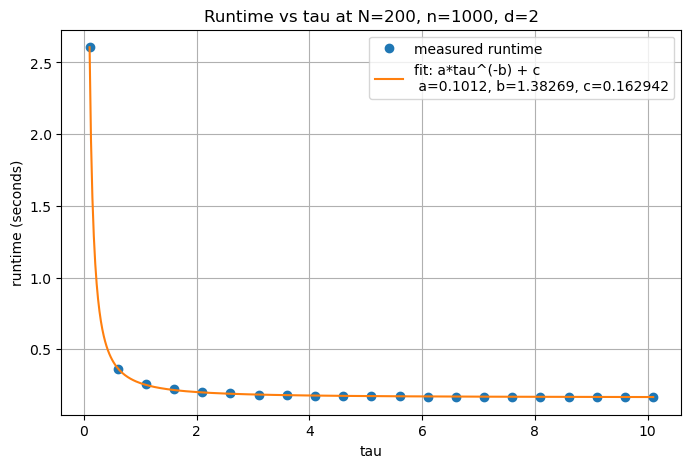

Highest shell: 46


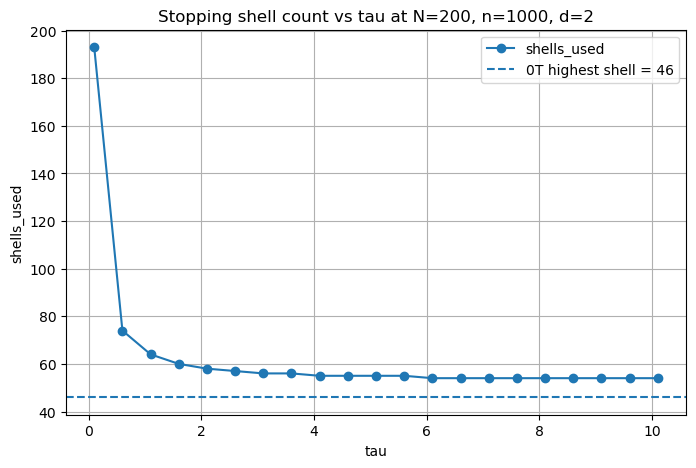

In [76]:
result = plot_runtime_vs_tau_negpow_fit(
    tau_start=0.1,
    tau_end=20.1,
    tau_step=0.5,
    N=200,
    n=1000,
    d=2,
    repeats=1
)

In [77]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def scaling_model_N_negpow(N, a, b, c):
    return a * (N ** (-b)) + c


def highest_shell_zero_temp_from_your_script(n):
    cur_lvl = 0
    total_eng = 0

    while n > 0:
        for i in range(0, cur_lvl):
            if n > 0:
                total_eng += cur_lvl - 1
                n -= 1
            else:
                break
        cur_lvl += 1

    highest_shell = cur_lvl
    print("Highest shell:", highest_shell)
    return highest_shell


def fit_runtime_vs_N_negpow(N_start, N_end, N_step, tau, n, d,
                            repeats=3, use_median=True, **logZ_kwargs):
    """
    Assumes fermion_logZ_numeric(..., return_all=True) returns:
        (logZ_n, logZ_array, info_dict)
    with info_dict containing:
        info["shells_used"]
    """
    N_vals = np.arange(N_start, N_end + 0.5 * N_step, N_step, dtype=int)
    runtimes = []
    shell_counts = []

    for N in N_vals:
        samples = []
        shell_used_this_N = None

        for _ in range(repeats):
            t0 = time.perf_counter()
            _, _, info = fermion_logZ_numeric(
                tau=tau,
                N=int(N),
                n=n,
                d=d,
                return_all=True,
                **logZ_kwargs
            )
            t1 = time.perf_counter()
            samples.append(t1 - t0)

            if shell_used_this_N is None:
                shell_used_this_N = info["shells_used"]

        runtime = float(np.median(samples) if use_median else np.mean(samples))
        runtimes.append(runtime)
        shell_counts.append(shell_used_this_N)

    runtimes = np.array(runtimes, dtype=float)
    shell_counts = np.array(shell_counts, dtype=int)

    c0 = float(runtimes.min())
    a0 = max(float(runtimes.max() - c0), 1e-12)
    b0 = 1.0

    popt, pcov = curve_fit(
        scaling_model_N_negpow,
        N_vals.astype(float),
        runtimes,
        p0=(a0, b0, c0),
        maxfev=20000
    )

    return {
        "N_vals": N_vals,
        "runtimes": runtimes,
        "shell_counts": shell_counts,
        "params": {
            "a": popt[0],
            "b": popt[1],
            "c": popt[2],
        },
        "cov": pcov,
    }


def plot_runtime_vs_N_negpow_fit(N_start, N_end, N_step, tau, n, d,
                                 repeats=3, use_median=True, print_shells=True,
                                 **logZ_kwargs):
    result = fit_runtime_vs_N_negpow(
        N_start=N_start,
        N_end=N_end,
        N_step=N_step,
        tau=tau,
        n=n,
        d=d,
        repeats=repeats,
        use_median=use_median,
        **logZ_kwargs
    )

    N_vals = result["N_vals"]
    runtimes = result["runtimes"]
    shell_counts = result["shell_counts"]
    a = result["params"]["a"]
    b = result["params"]["b"]
    c = result["params"]["c"]

    N_fit = np.linspace(N_vals.min(), N_vals.max(), 400)
    t_fit = scaling_model_N_negpow(N_fit, a, b, c)

    print(f"a = {a}")
    print(f"b = {b}")
    print(f"c = {c}")

    if print_shells:
        print("\nStopping shell count for each N:")
        for N, k in zip(N_vals, shell_counts):
            print(f"N = {int(N):6d}, shells_used = {k}")

    plt.figure(figsize=(8, 5))
    plt.plot(N_vals, runtimes, "o", label="measured runtime")
    plt.plot(
        N_fit,
        t_fit,
        label=f"fit: a*N^(-b) + c\n a={a:.6g}, b={b:.6g}, c={c:.6g}"
    )
    plt.xlabel("N")
    plt.ylabel("runtime (seconds)")
    plt.title(f"Runtime vs N at tau={tau}, n={n}, d={d}")
    plt.grid(True)
    plt.legend()
    plt.show()

    highest_shell_0T = highest_shell_zero_temp_from_your_script(n)

    plt.figure(figsize=(8, 5))
    plt.plot(N_vals, shell_counts, "o-", label="shells_used")
    plt.axhline(
        highest_shell_0T,
        linestyle="--",
        label=f"0T highest shell = {highest_shell_0T}"
    )
    plt.xlabel("N")
    plt.ylabel("shells_used")
    plt.title(f"Stopping shell count vs N at tau={tau}, n={n}, d={d}")
    plt.grid(True)
    plt.legend()
    plt.show()

    return result

a = 0.047348947698684814
b = 9.53498428086761e-05
c = -0.040862405130927475

Stopping shell count for each N:
N =      1, shells_used = 30
N =      2, shells_used = 30
N =      3, shells_used = 30
N =      4, shells_used = 30
N =      5, shells_used = 30
N =      6, shells_used = 30
N =      7, shells_used = 30
N =      8, shells_used = 30
N =      9, shells_used = 30
N =     10, shells_used = 30
N =     11, shells_used = 30
N =     12, shells_used = 30
N =     13, shells_used = 30
N =     14, shells_used = 30
N =     15, shells_used = 30
N =     16, shells_used = 30
N =     17, shells_used = 30
N =     18, shells_used = 30
N =     19, shells_used = 30
N =     20, shells_used = 30
N =     21, shells_used = 30
N =     22, shells_used = 30
N =     23, shells_used = 30
N =     24, shells_used = 30
N =     25, shells_used = 30
N =     26, shells_used = 30
N =     27, shells_used = 30
N =     28, shells_used = 30
N =     29, shells_used = 30
N =     30, shells_used = 30


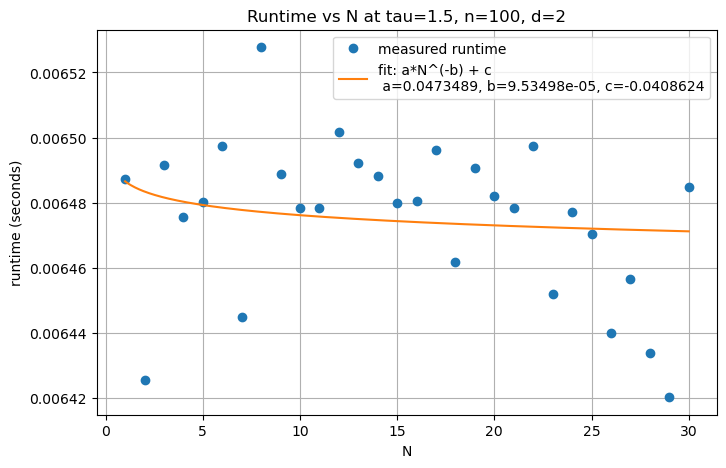

Highest shell: 15


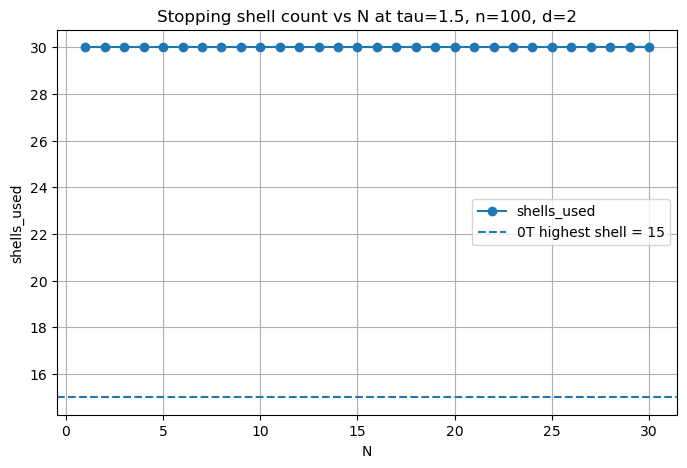

In [87]:
result = plot_runtime_vs_N_negpow_fit(
    N_start=1,
    N_end=30,
    N_step=1,
    tau=1.5,
    n=100,
    d=2,
    repeats=100
)